In [14]:
import numpy as np

rng = np.random.default_rng(0)

In [ ]:
''' Возьмем простые данные - n-мерное изотропное нормальное распределение N(0, I_d) '''

def logp(x):
    return -0.5 * np.dot(x, x)

def grad_logp(x):
    return -x

def your_data_utils(x):
    x = np.asarray(x)
    d = x.size
    mu = 3.0  
    w1 = 0.5
    w2 = 0.5
    m1 = np.zeros(d); m1[0] = +mu
    m2 = np.zeros(d); m2[0] = -mu

    diff1 = x - m1
    diff2 = x - m2

    logN1 = -0.5 * np.dot(diff1, diff1) - 0.5 * d * np.log(2 * np.pi)
    logN2 = -0.5 * np.dot(diff2, diff2) - 0.5 * d * np.log(2 * np.pi)

    a = np.log(w1) + logN1
    b = np.log(w2) + logN2
    m = max(a, b)
    logp_val = m + np.log(np.exp(a - m) + np.exp(b - m))

    num1 = np.exp(a - logp_val)  # γ1
    num2 = np.exp(b - logp_val)  # γ2
    grad_val = -(num1 * diff1 + num2 * diff2)

    return logp_val, grad_val


In [16]:
''' Посчитаем ESS через интегрированную автокорреляции '''

def ess(x):
    x = x - x.mean()

    acf = np.correlate(x, x, mode='full')
    acf = acf[len(acf) // 2:]
    acf /= acf[0]

    tau = 1 + 2 * np.sum(acf[1:200])

    return len(x) / tau

In [17]:
''' Базовая реализация MH алгоритма '''

def mh(x0, steps, scale):
    x = x0.copy()
    d = len(x)

    chain = np.zeros((steps, d))
    accept = 0

    for t in range(steps):
        prop = x + rng.normal(0, scale, size=d)

        if np.log(rng.uniform()) < (logp(prop) - logp(x)):
            x = prop; accept += 1

        chain[t] = x

    return chain, accept / steps

In [ ]:
def mala(x0, steps, step):
    x = x0.copy()
    d = len(x)

    chain = np.zeros((steps, d))
    accept = 0

    step2 = step ** 2
    half_step2 = 0.5 * step2

    def log_q(y, x):
        mean = x + half_step2 * grad_logp(x)
        diff = y - mean
        return -0.5 * np.dot(diff, diff) / step2 - 0.5 * d * np.log(2 * np.pi * step2)

    for t in range(steps):
        mean = x + half_step2 * grad_logp(x)
        prop = mean + step * rng.normal(size=d)
        log_alpha = (logp(prop) - logp(x)) + (log_q(x, prop) - log_q(prop, x))

        if np.log(rng.uniform()) < log_alpha:
            x = prop
            accept += 1

        chain[t] = x

    return chain, accept / steps


In [ ]:
d = 10
steps = 30000
burn = 5000
x0 = np.ones(d) * 3 

mala_step = 0.6
mh_scale = 2.4 / np.sqrt(d)

mh_chain, mh_acc = mh(x0, steps, scale=mh_scale)
mala_chain, mala_acc = mala(x0, steps, step=mala_step)

mh_s = mh_chain[burn:]
mala_s = mala_chain[burn:]

mh_ess = np.median([ess(mh_s[:, j]) for j in range(d)])
mala_ess = np.median([ess(mala_s[:, j]) for j in range(d)])

print(f"MH acceptance rate:    {mh_acc:.3f}")
print(f"MALA acceptance rate:  {mala_acc:.3f}")
print(f"MH median ESS (per dim):   {mh_ess:.1f}")
print(f"MALA median ESS (per dim): {mala_ess:.1f}")

MH acceptance rate:    0.259
MALA acceptance rate:  0.929
MH median ESS (per dim):   844.2
MALA median ESS (per dim): 2411.7


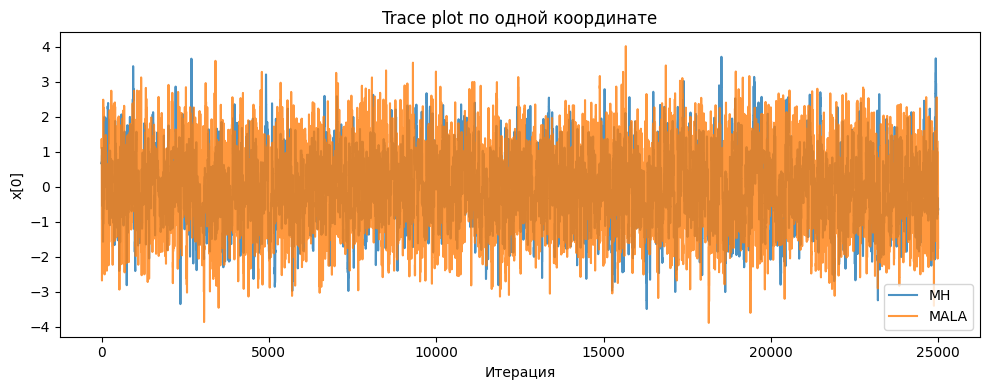

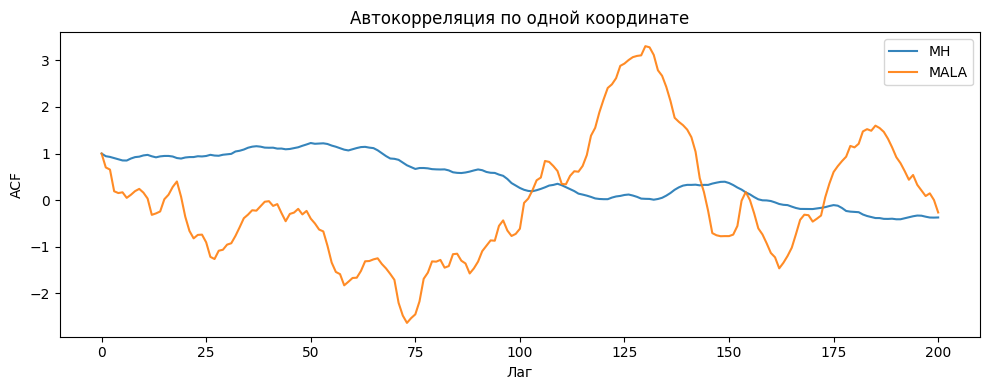

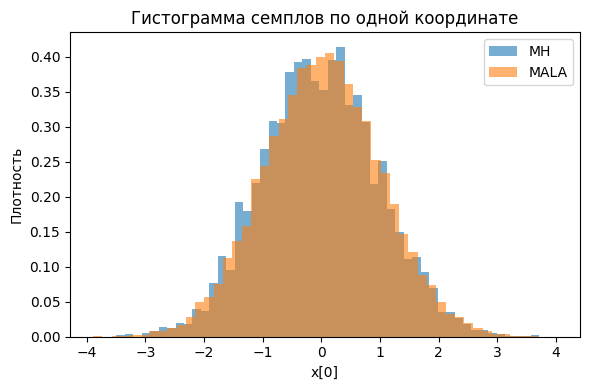

In [ ]:
import matplotlib.pyplot as plt

coord = 0

def acf_1d(x, max_lag=200):
    x = x - x.mean()
    c = np.correlate(x, x, mode='full')
    c = c[len(x)//2:len(x)//2 + max_lag + 1]
    return c / c[0]

plt.figure(figsize=(10, 4))
plt.plot(mh_s[:, coord], label='MH', alpha=0.8)
plt.plot(mala_s[:, coord], label='MALA', alpha=0.8)
plt.xlabel('Итерация')
plt.ylabel(f'x[{coord}]')
plt.title('Trace plot по одной координате')
plt.legend()
plt.tight_layout()
plt.show()

max_lag = 200
mh_acf = acf_1d(mh_s[:, coord], max_lag=max_lag)
mala_acf = acf_1d(mala_s[:, coord], max_lag=max_lag)

plt.figure(figsize=(10, 4))
plt.plot(range(max_lag + 1), mh_acf, label='MH', alpha=0.9)
plt.plot(range(max_lag + 1), mala_acf, label='MALA', alpha=0.9)
plt.xlabel('Лаг')
plt.ylabel('ACF')
plt.title('Автокорреляция по одной координате')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(mh_s[:, coord], bins=50, density=True, alpha=0.6, label='MH')
plt.hist(mala_s[:, coord], bins=50, density=True, alpha=0.6, label='MALA')
plt.xlabel(f'x[{coord}]')
plt.ylabel('Плотность')
plt.title('Гистограмма семплов по одной координате')
plt.legend()
plt.tight_layout()
plt.show()


Вывод
MALA работает лучше, тк она использует направление градиента и быстрее перемешивает цепь, поэтому даёт больше полезных семплов за то же число шагов. На смеси из двух пиков обеим методам трудно перепрыгивать между пиками, но внутри одного пика MALA всё равно эффективнее.